# 03 — Adaptive reserve moderation figure

Renders the multi-panel figure and saves vector/raster exports to `figures/`.

**Requires:** subject-level CSV from `01_data.ipynb`.

**Outputs:** `figures/adaptive_reserve_moderation.{png,pdf,svg,eps}`


N = 43 subjects
F(3, 39) = 4.38, p = 0.0094, R2 = 0.252
b_X = -0.147, p = 0.311; b_M = -0.070, p = 0.645; b_int = 0.389, p = 0.0060
Johnson-Neyman roots ($M_{\mathit{Z}}$): [np.float64(-0.36048865077630654), np.float64(2.204632919323197)]
 -1 $\mathit{SD}$: b = -0.536, SE = 0.176, p = 0.0042
 $\mathit{Mean}$: b = -0.147, SE = 0.143, p = 0.3114
 +1 $\mathit{SD}$: b = 0.243, SE = 0.214, p = 0.2630


[figure] saved adaptive_reserve_moderation.png: 7645x4103 -> 7446x3758 px (border=3px/side, Δ=-199x-345; edge α max={'top': 0, 'bottom': 0, 'left': 0, 'right': 0}; PNG has transparent margin, PDF shows as white)
Saved: D:\文件同步\文件\数据分析结果\data_code_figure\adaptive_reserve_moderate\figures\adaptive_reserve_moderation.png


[figure] saved adaptive_reserve_moderation.pdf: 7645x4103 -> 7446x3758 px (border=3px/side, Δ=-199x-345; edge α max={'top': 0, 'bottom': 0, 'left': 0, 'right': 0}; PNG has transparent margin, PDF shows as white)
Saved: D:\文件同步\文件\数据分析结果\data_code_figure\adaptive_reserve_moderate\figures\adaptive_reserve_moderation.pdf


Saved: D:\文件同步\文件\数据分析结果\data_code_figure\adaptive_reserve_moderate\figures\adaptive_reserve_moderation.svg


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: D:\文件同步\文件\数据分析结果\data_code_figure\adaptive_reserve_moderate\figures\adaptive_reserve_moderation.eps


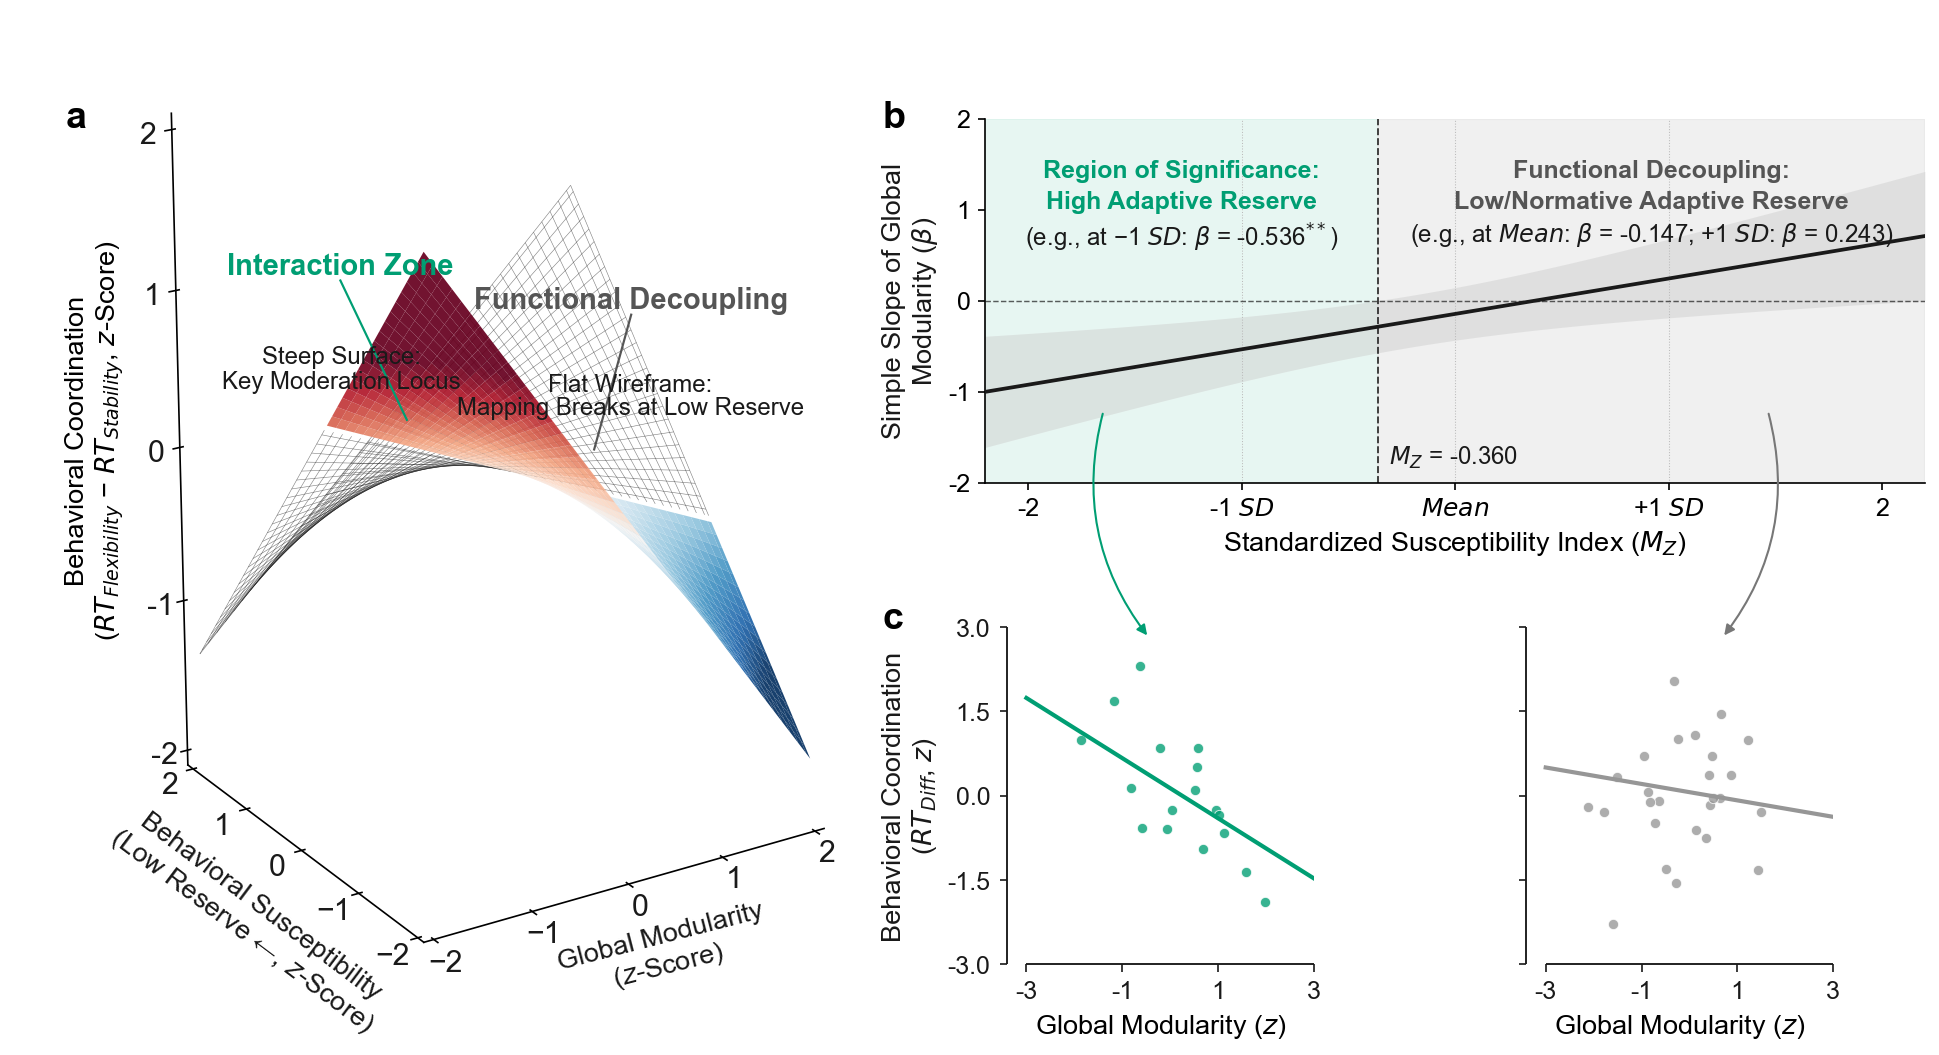

In [1]:
# =============================================================================
# Adaptive Reserve Gates the Topology-Behavior Mapping
# X = global_modularity_auc | Y = rt_transition_diff__flexibility_stability
# Moderator = rt_duration_diff__long-short | States = 3-6
# =============================================================================
import warnings
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D, proj3d  # noqa: F401
from scipy import stats as scipy_stats
from statsmodels.api import OLS, add_constant

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

_SMALL_WORDS = frozenset({
    "a", "an", "and", "at", "but", "by", "for", "from", "in", "into",
    "nor", "of", "on", "or", "the", "to", "vs", "via", "with", "as",
})


def title_case_figure(text: str) -> str:
    """Capitalize words; keep small words lowercase except first/last per line."""
    if not text or not isinstance(text, str):
        return text

    def _cap_plain(seg: str) -> str:
        lines_out = []
        for line in seg.split("\n"):
            tokens = re.findall(r"[A-Za-z][A-Za-z'-]*|[^A-Za-z]+", line)
            word_idx = [i for i, t in enumerate(tokens) if re.match(r"[A-Za-z]", t)]
            if not word_idx:
                lines_out.append(line)
                continue
            new_tokens = list(tokens)
            for wi, ti in enumerate(word_idx):
                w = tokens[ti]
                wl = w.lower()
                if 0 < wi < len(word_idx) - 1 and wl in _SMALL_WORDS:
                    new_tokens[ti] = wl
                elif len(w) > 1:
                    new_tokens[ti] = w[0].upper() + w[1:].lower()
                else:
                    new_tokens[ti] = w.upper()
            lines_out.append("".join(new_tokens))
        return "\n".join(lines_out)

    parts = re.split(r"(\$[^$]*\$)", text)
    result = "".join(p if p.startswith("$") else _cap_plain(p) for p in parts)
    result = re.sub(r"(?i)\be\.g\.", "e.g.", result)
    result = re.sub(r"(?<![A-Za-z])Sd(?![A-Za-z])", "SD", result)
    return result


def _package_dir(cwd=None):
    root = (cwd or Path.cwd()).resolve()
    if (root / "data").is_dir() and (root / "notebooks").is_dir():
        return root
    if root.name == "notebooks" and (root.parent / "data").is_dir():
        return root.parent
    if (root / "01_analysis.ipynb").exists() or (root / "02_plot.ipynb").exists():
        return root
    pkg = root / "adaptive_reserve_moderation_analysis"
    if (pkg / "notebooks" / "01_analysis.ipynb").exists():
        return pkg
    return root


PACKAGE_DIR = _package_dir()
FIG_OUT_DIR = PACKAGE_DIR / "figures"
FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Teal accent (Wong 2011; colorblind-safe). panel a mesh stays RdBu_r.
BLUE, BLUE_LIGHT = "#009E73", "#D5F0E8"
GRAY, GRAY_LIGHT, TEXT = "#969696", "#E8E8E8", "#1A1A1A"
FS = 13
FS_TICK = 12
FS_TITLE = 13.5
FS_PANEL = 18
FS_SMALL = 11.5
FS_ANN = 12
FS_ANN_ZONE = FS_ANN + 2
FS_3D_TICK = 11

# Italic mathtext for statistical notation (Z, SD, Mean)
_Z = r"$\mathit{Z}$"
_MZ = r"$M_{\mathit{Z}}$"
_z = r"$\mathit{z}$"
_SD = r"$\mathit{SD}$"
_MEAN = r"$\mathit{Mean}$"

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": FS,
    "axes.linewidth": 0.8,
    "axes.labelsize": FS,
    "axes.titlesize": FS_TITLE,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_TICK,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def zscore(s):
    return (s - s.mean()) / s.std(ddof=1)


def fit_moderation(df):
    x = zscore(df["global_modularity_auc"])
    m = zscore(df["rt_duration_diff__long-short"])
    y = zscore(df["rt_transition_diff__flexibility_stability"])
    xm = x * m
    design = add_constant(np.column_stack([x, m, xm]))
    model = OLS(y, design).fit()
    cov = np.asarray(model.cov_params())
    b1 = float(model.params.iloc[1])
    b3 = float(model.params.iloc[3])
    v11, v13, v33 = cov[1, 1], cov[1, 3], cov[3, 3]
    df_resid = model.df_resid
    return {
        "model": model,
        "x_z": x,
        "m_z": m,
        "y_z": y,
        "b1": b1,
        "b3": b3,
        "v11": v11,
        "v13": v13,
        "v33": v33,
        "df_resid": df_resid,
        "df_raw": df,
    }


def simple_slope(b1, b3, m, v11, v13, v33, df):
    theta = b1 + b3 * m
    var = v11 + 2 * m * v13 + m * m * v33
    se = np.sqrt(max(var, 0))
    t = theta / se if se > 0 else np.nan
    p = 2 * (1 - scipy_stats.t.cdf(abs(t), df)) if np.isfinite(t) else np.nan
    tc = scipy_stats.t.ppf(0.975, df)
    return theta, se, t, p, theta - tc * se, theta + tc * se


def _jn_roots(b1, b3, v11, v13, v33, df):
    tc = scipy_stats.t.ppf(0.975, df)
    t2 = tc * tc
    A = b3 * b3 - t2 * v33
    B = 2 * (b1 * b3 - t2 * v13)
    C = b1 * b1 - t2 * v11
    if abs(A) < 1e-12:
        if abs(B) < 1e-12:
            return []
        return [-C / B]
    disc = B * B - 4 * A * C
    if disc < 0:
        return []
    s = np.sqrt(disc)
    return sorted([(-B - s) / (2 * A), (-B + s) / (2 * A)])


def slope_curve(fit, m_grid):
    b1, b3 = fit["b1"], fit["b3"]
    v11, v13, v33, df = fit["v11"], fit["v13"], fit["v33"], fit["df_resid"]
    theta = b1 + b3 * m_grid
    var = v11 + 2 * m_grid * v13 + m_grid ** 2 * v33
    se = np.sqrt(np.maximum(var, 0))
    tc = scipy_stats.t.ppf(0.975, df)
    return theta, theta - tc * se, theta + tc * se


# --- load data & fit moderation ---
DATA_CSV = PACKAGE_DIR / "data" / "adaptive_reserve_moderation_subject_level.csv"
fig_df = pd.read_csv(DATA_CSV)
print(f"N = {len(fig_df)} subjects")

fig_fit = fit_moderation(fig_df)
_model = fig_fit["model"]
print(
    f"F({_model.df_model:.0f}, {_model.df_resid:.0f}) = {_model.fvalue:.2f}, "
    f"p = {_model.f_pvalue:.4f}, R2 = {_model.rsquared:.3f}"
)
print(
    f"b_X = {_model.params.iloc[1]:.3f}, p = {_model.pvalues.iloc[1]:.3f}; "
    f"b_M = {_model.params.iloc[2]:.3f}, p = {_model.pvalues.iloc[2]:.3f}; "
    f"b_int = {_model.params.iloc[3]:.3f}, p = {_model.pvalues.iloc[3]:.4f}"
)

jn_roots = _jn_roots(
    fig_fit["b1"], fig_fit["b3"],
    fig_fit["v11"], fig_fit["v13"], fig_fit["v33"], fig_fit["df_resid"],
)
jn_lo = jn_roots[0] if jn_roots else -0.360
print(f"Johnson-Neyman roots ({_MZ}): {jn_roots}")
for _lab, _mz in [(f"-1 {_SD}", -1), (_MEAN, 0), (f"+1 {_SD}", 1)]:
    _th, _se, _t, _p, _, _ = simple_slope(
        fig_fit["b1"], fig_fit["b3"], _mz,
        fig_fit["v11"], fig_fit["v13"], fig_fit["v33"], fig_fit["df_resid"],
    )
    print(f" {_lab}: b = {_th:.3f}, SE = {_se:.3f}, p = {_p:.4f}")


# --- panels ---
PANEL_A_ELEMENT_SCALE = 1.32
PANEL_A_VSHIFT_UP = 0.05
PANEL_A_GLOBAL_Y_SHIFT = 0.11
FS_PANEL_A_AXIS = FS
PANEL_A_SIZE_SCALE = 1.5 * PANEL_A_ELEMENT_SCALE * 1.2 * 0.9 * 1.05
PANEL_A_MESH_N = 90
PANEL_A_CONTENT_LEFT_FRAC = 0.5
PANEL_A_SHIFT_RIGHT = 0.038
PANEL_A_NUDGE_RIGHT_FIG = 0.016 # extra rightward shift for all panel a content
PANEL_A_LABEL_X = -0.07
PANEL_A_LABEL_DX_FIG = 0.0 # panel a label left edge aligns with Z-axis title left
PANEL_C_LABEL_UP_EM = 0.5 # vertical offset in em above C anchor (↓ half em vs prior)
PANEL_C_LABEL_DOWN_EM = 1.0 # extra downward shift for panel c label (in panel-label em)
PANEL_A_Z_TICK_NUDGE_PT = 5
PANEL_A_XY_LABELPAD = 14
PANEL_A_XY_TICK_DY_PT = 10
PANEL_A_Z_TICK_DX_PT = 5
PANEL_A_Z_TICK_DY_PT = 2
PANEL_A_X_TICK_DX_PT = 1
PANEL_A_X_TICK_DY_PT = 7
PANEL_A_XY_TICK_DX_PT = 10
PANEL_A_Y_TICK_UL_DX_PT = -4
PANEL_A_Y_TICK_UL_DY_PT = 8
PANEL_A_XY_LABEL_DY_PT = 24
PANEL_A_XY_LABEL_DX_PT = 24
PANEL_A_Y_LABEL_EXTRA_DX_PT = -8
PANEL_A_Y_LABEL_EXTRA_DY_PT = -7
PANEL_B_YLIM = (-2.0, 2.0)
PANEL_B_YSTEP = 1.0
PANEL_B_ROW_HEIGHT = 1.2 * 0.9
PANEL_B_WIDTH_SCALE = 0.95 # axes bbox width (NOT set_aspect)
PANEL_B_HEIGHT_SCALE = 1.08 # 1.2 × 0.9; axes bbox height multiplier
PANEL_B_AB_DOWN_FIG = 0.026 # downward nudge: panel b + a/b labels as one block
PANEL_C_WIDTH_SCALE = 1.188 # 1.08 × 1.1; C subplot width multiplier
PANEL_C_HEIGHT_SCALE = 1.134 # 1.08 × 1.05; C subplot height multiplier
PANEL_A_X_LABEL_EXTRA_DX_PT = 34 # nudge X title toward upper-right
PANEL_A_X_LABEL_EXTRA_DY_PT = 11
PANEL_A_Z_LABEL_COORDS_X = -0.010 # nudge Z title slightly right
PANEL_BC_LABEL_X = -0.14
PANEL_BC_LABEL_Y = 1.06
PANEL_C_LABEL_Y = 1.02
PANEL_C_X_SHIFT_PT = 13 # gap between broken Y and X axes (~2/3 of prior 20 pt)
PANEL_C_XLIM = (-3.0, 3.0)
PANEL_C_XSTEP = 2.0
PANEL_C_X_WIDTH_SCALE = 0.8
PANEL_C_TICK_LEN_PT = 4
PANEL_C_YLIM = (-3.0, 3.0)
PANEL_C_YSTEP = 1.5
PANEL_A_ZONE_SUB_DY = 0.15
PANEL_C_NUDGE_DOWN_FIG = 0.04
PANEL_C_NUDGE_UP_CHARS = 2 # shift entire panel c upward
PANEL_C_CONTENT_EXTRA_DOWN_FIG = 0.014 # extra downward nudge after C label (content only)
PANEL_C_FINAL_DOWN_FIG = 0.016 # final downward nudge after C size scaling
PANEL_C_RIGHT_NUDGE_RIGHT_CHARS = 4 # shift right C subplot slightly right
PANEL_BC_GRAY_ARROW_NUDGE_CHARS = 2 # nudge gray B→C arrow rightward
PANEL_B_JN_LABEL_Y = -1.58 # M_Z boundary label (up from -1.75)
FIG_SAVE_ALPHA_THRESH = 12 # alpha > thresh counts as content for border crop
FIG_SAVE_BORDER_PX = 3 # target transparent margin (pixels per side)
FIG_SAVE_BORDER_MIN_PX = 1 # minimum margin if target cannot be met
PANEL_C_GAP_CLOSE_FRAC = 0.12 # close this fraction of L–R gap (move R left)
PANEL_C_RIGHT_SHIFT_CHARS = 5 # extra left shift of right C subplot
PANEL_BC_ARROW_LEN_FRAC = 1.584 # 0.792 × 2
PANEL_BC_ARROW_RAD = 0.25
PANEL_BC_ARROW_OUTWARD_FIG = 0.028
PANEL_BC_ARROW_UP_FIG = 0.022
PANEL_BC_ARROW_DOWN_FIG = 0.014 # nudge green/gray B→C arrows downward
PANEL_A_NUDGE_UP_FIG = 0.13
PANEL_A_NUDGE_DOWN_CHARS = 1 # lower panel a content slightly (not the a label)
PANEL_BC_NUDGE_LEFT_CHARS = 2 # shift b/c content left (not the b/c labels)
N_AXIS_TICKS = 5

def _ticks_even(vmin, vmax, n=N_AXIS_TICKS):
    return np.linspace(vmin, vmax, n)


def _set_2d_ticks(ax, xlim, ylim, n=N_AXIS_TICKS):
    ax.set_xticks(_ticks_even(xlim[0], xlim[1], n))
    ax.set_yticks(_ticks_even(ylim[0], ylim[1], n))


def _panel_a_scaled_fs(fs):
    return fs * PANEL_A_ELEMENT_SCALE


def _set_3d_ticks(ax, n=N_AXIS_TICKS):
    ax.set_xticks(_ticks_even(-2, 2, n))
    ax.set_yticks(_ticks_even(-2, 2, n))
    zticks = np.arange(-2, 3, 1)
    ax.set_zticks(zticks)
    ax.set_zticklabels([f"{t:.0f}" for t in zticks])










def _clear_panel_a_text_overlays(extras):
    # zone_ann_artists managed separately — do not clear here
    for key in ("xy_tick_texts", "z_tick_texts", "axis_label_texts"):
        for artist in extras.get(key, []):
            try:
                artist.remove()
            except Exception:
                pass
        extras[key] = []


def _tick_label_text(axis, tick, z_axis=False):
    text = tick.label1.get_text().strip()
    if text:
        return text
    val = tick.get_loc()
    return f"{val:.0f}" if z_axis else f"{val:g}"


def _panel_a_xy_axis_segments(ax):
    """3D endpoints of visible X/Y axis lines (front-bottom face)."""
    xs = sorted(ax.get_xlim())
    ys = sorted(ax.get_ylim())
    zs = sorted(ax.get_zlim())
    x_seg = ((xs[0], ys[1], zs[0]), (xs[1], ys[1], zs[0]))
    y_seg = ((xs[0], ys[0], zs[0]), (xs[0], ys[1], zs[0]))
    return x_seg, y_seg


def _project_3d_to_figure(fig, ax, xyz):
    x2, y2, _ = proj3d.proj_transform(*xyz, ax.get_proj())
    disp = ax.transData.transform((x2, y2))
    return fig.transFigure.inverted().transform(disp)


def _place_panel_a_rotated_axis_label(
    fig, ax, p0_3d, p1_3d, text, offset_pt, extras, extra_dx_pt=0.0, extra_dy_pt=0.0,
):
    """Place axis title centered on, and parallel to, the projected axis line."""
    f0 = _project_3d_to_figure(fig, ax, p0_3d)
    f1 = _project_3d_to_figure(fig, ax, p1_3d)
    mid = 0.5 * (f0 + f1)
    d0 = fig.transFigure.transform(f0)
    d1 = fig.transFigure.transform(f1)
    dx_px = d1[0] - d0[0]
    dy_px = d1[1] - d0[1]
    angle = float(np.degrees(np.arctan2(dy_px, dx_px)))
    if angle > 90:
        angle -= 180
    elif angle < -90:
        angle += 180
    length = np.hypot(dx_px, dy_px) or 1.0
    nx, ny = -dy_px / length, dx_px / length
    scale = fig.dpi / 72.0
    off = offset_pt * scale
    dmid = fig.transFigure.transform(mid)
    cx = dmid[0] + nx * off + extra_dx_pt * scale
    cy = dmid[1] + ny * off + extra_dy_pt * scale
    fx, fy = fig.transFigure.inverted().transform((cx, cy))
    t = fig.text(
        fx, fy, text, fontsize=FS_PANEL_A_AXIS, ha="center", va="center",
        rotation=angle, rotation_mode="anchor", color=TEXT, clip_on=False,
    )
    extras["axis_label_texts"].append(t)


def _place_panel_a_x_label_near_ticks(fig, ax, x_seg, text, x_tick_bboxes, extras):
    """X title: center-aligned, placed lower-right beside the axis ticks."""
    f0 = _project_3d_to_figure(fig, ax, x_seg[0])
    f1 = _project_3d_to_figure(fig, ax, x_seg[1])
    d0 = fig.transFigure.transform(f0)
    d1 = fig.transFigure.transform(f1)
    angle = float(np.degrees(np.arctan2(d1[1] - d0[1], d1[0] - d0[0])))
    if angle > 90:
        angle -= 180
    elif angle < -90:
        angle += 180
    anchor = d1 if d1[0] >= d0[0] else d0
    cy_ticks = min(0.5 * (bb.y0 + bb.y1) for bb in x_tick_bboxes) if x_tick_bboxes else anchor[1]
    scale = fig.dpi / 72.0 * PANEL_A_ELEMENT_SCALE
    cx = anchor[0] + PANEL_A_X_LABEL_EXTRA_DX_PT * scale
    cy = min(anchor[1], cy_ticks) + PANEL_A_X_LABEL_EXTRA_DY_PT * scale
    fx, fy = fig.transFigure.inverted().transform((cx, cy))
    label_text = "\n".join(ln.strip() for ln in text.split("\n") if ln.strip())
    t = fig.text(
        fx, fy, label_text, fontsize=FS_PANEL_A_AXIS, ha="center", va="center",
        rotation=angle, rotation_mode="anchor", color=TEXT, clip_on=False,
    )
    extras["axis_label_texts"].append(t)


def _apply_panel_a_axis_overlays(fig, ax, extras):
    """Nudge 3D tick values and axis titles (mplot3d resets transforms on draw)."""
    _clear_panel_a_text_overlays(extras)
    extras.setdefault("xy_tick_texts", [])
    extras.setdefault("z_tick_texts", [])
    extras.setdefault("axis_label_texts", [])
    _set_3d_ticks(ax)
    for tick in ax.xaxis.get_major_ticks() + ax.yaxis.get_major_ticks() + ax.zaxis.get_major_ticks():
        tick.label1.set_visible(True)
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    ax.xaxis.labelpad = PANEL_A_XY_LABELPAD
    ax.yaxis.labelpad = PANEL_A_XY_LABELPAD
    ax.tick_params(axis="z", pad=PANEL_A_Z_TICK_NUDGE_PT + 1)
    _s = PANEL_A_ELEMENT_SCALE
    dy_y_ul_px = PANEL_A_Y_TICK_UL_DY_PT * fig.dpi / 72.0 * _s
    dx_y_ul_px = PANEL_A_Y_TICK_UL_DX_PT * fig.dpi / 72.0 * _s
    x_tick_bboxes = []
    for axis_name in ("x", "y"):
        axis = getattr(ax, axis_name + "axis")
        if axis_name == "x":
            dx_px = PANEL_A_X_TICK_DX_PT * fig.dpi / 72.0 * _s
            dy_px = PANEL_A_X_TICK_DY_PT * fig.dpi / 72.0 * _s
        else:
            dx_px, dy_px = dx_y_ul_px, dy_y_ul_px
        for tick in axis.get_major_ticks():
            lbl = tick.label1
            text = _tick_label_text(axis, tick)
            bb = lbl.get_window_extent(renderer)
            if axis_name == "x":
                x_tick_bboxes.append(bb)
            lbl.set_visible(False)
            cx = 0.5 * (bb.x0 + bb.x1) + dx_px
            cy = 0.5 * (bb.y0 + bb.y1) + dy_px
            fx, fy = fig.transFigure.inverted().transform((cx, cy))
            t = fig.text(
                fx, fy, text, fontsize=_panel_a_scaled_fs(FS_3D_TICK),
                ha="center", va="center", color=TEXT, clip_on=False,
            )
            extras["xy_tick_texts"].append(t)

    zdx_px = PANEL_A_Z_TICK_DX_PT * fig.dpi / 72.0 * PANEL_A_ELEMENT_SCALE
    zdy_px = PANEL_A_Z_TICK_DY_PT * fig.dpi / 72.0 * PANEL_A_ELEMENT_SCALE
    for tick in ax.zaxis.get_major_ticks():
        lbl = tick.label1
        text = _tick_label_text(ax.zaxis, tick, z_axis=True)
        bb = lbl.get_window_extent(renderer)
        lbl.set_visible(False)
        cx = 0.5 * (bb.x0 + bb.x1) + zdx_px
        cy = 0.5 * (bb.y0 + bb.y1) + zdy_px
        fx, fy = fig.transFigure.inverted().transform((cx, cy))
        t = fig.text(
            fx, fy, text, fontsize=_panel_a_scaled_fs(FS_3D_TICK),
            ha="center", va="center", color=TEXT, clip_on=False,
        )
        extras["z_tick_texts"].append(t)

    ax.xaxis.label.set_visible(False)
    ax.yaxis.label.set_visible(False)
    ax.zaxis.label.set_visible(True)
    ax.zaxis.label.set_fontsize(FS_PANEL_A_AXIS)
    x_lbl_text = title_case_figure(ax.xaxis.label.get_text())
    y_lbl_text = title_case_figure(ax.yaxis.label.get_text())
    ax.zaxis.label.set_text(title_case_figure(ax.zaxis.label.get_text()))
    fig.canvas.draw()
    x_seg, y_seg = _panel_a_xy_axis_segments(ax)
    _place_panel_a_x_label_near_ticks(fig, ax, x_seg, x_lbl_text, x_tick_bboxes, extras)
    _place_panel_a_rotated_axis_label(
        fig, ax, y_seg[0], y_seg[1], y_lbl_text, PANEL_A_XY_LABEL_DX_PT, extras,
        extra_dx_pt=PANEL_A_Y_LABEL_EXTRA_DX_PT,
        extra_dy_pt=PANEL_A_Y_LABEL_EXTRA_DY_PT,
    )
    fig.canvas.draw()


def _panel_a_hide_pane_grids(ax):
    """Remove 3D axis background (pane) grid lines."""
    ax.grid(False)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis._axinfo["grid"].update(color=(1.0, 1.0, 1.0, 0.0), linewidth=0)
        axis.pane.set_edgecolor("none")
        axis.pane.fill = False


def _panel_a_is_surface_poly(col):
    """True for 3D surface face collection from plot_surface (not wireframe lines)."""
    return col.__class__.__name__ == "Poly3DCollection"


def _panel_a_strip_surface_mesh(ax):
    """Remove face-edge / mesh lines on plot_surface only (keep wireframe lines)."""
    for col in ax.collections:
        if not _panel_a_is_surface_poly(col):
            continue
        try:
            col.set_linewidths(0)
        except Exception:
            try:
                col.set_linewidth(0)
            except Exception:
                pass
        for setter in ("set_edgecolors", "set_edgecolor"):
            try:
                getattr(col, setter)("none")
                break
            except Exception:
                continue


def _panel_a_pred_z(fit, x, m):
    b0, b1, b2, b3 = [float(v) for v in fit["model"].params.iloc[:4]]
    return b0 + b1 * x + b2 * m + b3 * x * m


def _apply_panel_a_zone_annotations(fig, ax, fit, jn_lo, extras):
    """Label Interaction Zone (steep surface) and Functional Decoupling (flat wireframe)."""
    extras.setdefault("zone_ann_artists", [])
    for artist in extras["zone_ann_artists"]:
        try:
            artist.remove()
        except Exception:
            pass
    extras["zone_ann_artists"] = []
    m_iz = float(np.clip(jn_lo - 0.35, -1.9, jn_lo - 0.05))
    x_iz = -1.4
    z_iz = _panel_a_pred_z(fit, x_iz, m_iz)
    m_fd = float(np.clip(jn_lo + 0.55, jn_lo + 0.15, 1.85))
    x_fd = 1.1
    z_fd = _panel_a_pred_z(fit, x_fd, m_fd)
    iz_lbl = (x_iz - 0.9, m_iz - 0.45, z_iz + 1.05)
    fd_lbl = (x_fd + 0.75, m_fd + 0.55, z_fd + 0.65)
    ann_specs = [
        ((x_iz, m_iz, z_iz), iz_lbl, title_case_figure("Interaction Zone"),
         [title_case_figure("Steep surface:"), title_case_figure("key moderation locus")], BLUE),
        ((x_fd, m_fd, z_fd), fd_lbl, title_case_figure("Functional Decoupling"),
         [title_case_figure("Flat wireframe:"), title_case_figure("mapping breaks at low reserve")], "#555555"),
    ]
    sub_dy = PANEL_A_ZONE_SUB_DY
    for anchor, lbl, title, sub_lines, color in ann_specs:
        ln, = ax.plot(
            [lbl[0], anchor[0]], [lbl[1], anchor[1]], [lbl[2], anchor[2]],
            color=color, lw=1.05, zorder=18, clip_on=False,
        )
        artists = [ln]
        t1 = ax.text(
            *lbl, title, fontsize=FS_ANN_ZONE, color=color, fontweight="bold",
            ha="center", va="bottom", zorder=19, clip_on=False,
        )
        artists.append(t1)
        for i, line in enumerate(sub_lines):
            t = ax.text(
                lbl[0], lbl[1], lbl[2] - 0.38 - i * sub_dy, line,
                fontsize=FS_SMALL, color=TEXT, ha="center", va="top",
                zorder=19, clip_on=False,
            )
            artists.append(t)
        extras["zone_ann_artists"].extend(artists)
    fig.canvas.draw()


def _shift_panel_a_body_right(fig, ax, extras):
    if PANEL_A_SHIFT_RIGHT <= 0:
        return
    pos = ax.get_position()
    ax.set_position([pos.x0 + PANEL_A_SHIFT_RIGHT, pos.y0, pos.width, pos.height])
    fig.canvas.draw()


def _panel_a_target_center_y(fig, ref_axes=None):
    sp = fig.subplotpars
    canvas_cy = (sp.bottom + sp.top) / 2
    if ref_axes is None:
        return canvas_cy
    ax_b, ax_l = ref_axes
    pos_b, pos_l = ax_b.get_position(), ax_l.get_position()
    bc_cy = (pos_b.y0 + pos_l.y1) / 2
    return (canvas_cy + bc_cy) / 2


def _apply_panel_a_layout(fig, ax, extras, ref_axes=None):
    fig.canvas.draw()
    try:
        ax.set_box_aspect((1, 1, 1.5))
    except AttributeError:
        pass
    fig.canvas.draw()
    sp = fig.subplotpars
    pos = ax.get_position()
    height = min(pos.height * 0.84 * PANEL_A_SIZE_SCALE, sp.top - sp.bottom - 0.03)
    col_w = pos.width
    width = col_w * PANEL_A_SIZE_SCALE
    x0_centered = pos.x0 - (width - col_w) / 2
    target_cy = _panel_a_target_center_y(fig, ref_axes) + PANEL_A_VSHIFT_UP + PANEL_A_GLOBAL_Y_SHIFT
    new_y0 = target_cy - height / 2
    new_y0 = float(np.clip(new_y0, sp.bottom, sp.top - height))
    ax.set_position([x0_centered, new_y0, width, height])
    fig.canvas.draw()
    ax.zaxis.label.set_rotation(90)
    _shift_panel_a_content_left(fig, ax, extras)
    _shift_panel_a_body_right(fig, ax, extras)


def _shift_panel_a_content_left(fig, ax, extras):
    fig.canvas.draw()
    pos = ax.get_position()
    shift = pos.width * PANEL_A_CONTENT_LEFT_FRAC
    new_x0 = pos.x0 - shift
    new_width = pos.width + shift
    ax.set_position([new_x0, pos.y0, new_width, pos.height])
    fig.canvas.draw()



def _panel_bc_label_bottom(fig, ax_ref, x_axes=PANEL_BC_LABEL_X, y_axes=PANEL_BC_LABEL_Y):
    fig.canvas.draw()
    pt_top = ax_ref.transAxes.transform((x_axes, y_axes))
    text_h = FS_PANEL / 72.0 * fig.dpi
    pt_bot = (pt_top[0], pt_top[1] - text_h)
    return fig.transFigure.inverted().transform(pt_bot)




def _panel_bc_label_figure_x(fig, ax_b, ylab_artist=None):
    """Figure-x for b/c panel labels: left edge of B y-axis title (overlay if given)."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    if ylab_artist is not None:
        bb = ylab_artist.get_window_extent(renderer)
    else:
        bb = ax_b.yaxis.label.get_window_extent(renderer)
    fx, _ = fig.transFigure.inverted().transform((bb.x0, 0))
    return fx


def place_panel_bc_label(fig, ref_ax, letter, ylab_artist=None, x_axes=None, y_axes=None):
    """Panel label: bottom-aligned with A; left edge at B y-axis title."""
    x_axes = PANEL_BC_LABEL_X if x_axes is None else x_axes
    y_axes = PANEL_BC_LABEL_Y if y_axes is None else y_axes
    fig.canvas.draw()
    fig_x = _panel_bc_label_figure_x(fig, ref_ax, ylab_artist=ylab_artist)
    _, fig_y = _panel_bc_label_bottom(fig, ref_ax, x_axes, y_axes)
    fig.text(
    fig_x, fig_y, letter, fontsize=FS_PANEL, fontweight="bold",
    va="bottom", ha="left", clip_on=False,
    )


def place_panel_c_label(fig, ax_b, ax_l, ylab_artist=None):
    """c label: same figure-x as B (y-axis title); y from panel c anchor."""
    fig.canvas.draw()
    fig_x = _panel_bc_label_figure_x(fig, ax_b, ylab_artist=ylab_artist)
    pt_cy = ax_l.transAxes.transform((0.0, PANEL_C_LABEL_Y))
    _, fy_c = fig.transFigure.inverted().transform(pt_cy)
    em_fig = (FS_PANEL / 72.0 * fig.dpi) / fig.bbox.height
    fig.text(
    fig_x, fy_c + em_fig * (1 + PANEL_C_LABEL_UP_EM - PANEL_C_LABEL_DOWN_EM), "c", fontsize=FS_PANEL, fontweight="bold",
    va="top", ha="left", clip_on=False,
    )





def _align_panel_c_left_ylabel(fig, ax_b, ax_l):
    """Shift left C subplot right so y-axis title aligns with panel b."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bb_b = ax_b.yaxis.label.get_window_extent(renderer)
    bb_l = ax_l.yaxis.label.get_window_extent(renderer)
    dx_px = bb_b.x0 - bb_l.x0
    if abs(dx_px) < 0.5:
        return
    inv = fig.transFigure.inverted()
    dfig = inv.transform((dx_px, 0))[0] - inv.transform((0, 0))[0]
    pos = ax_l.get_position()
    ax_l.set_position([pos.x0 + dfig, pos.y0, pos.width, pos.height])
    fig.canvas.draw()


def place_panel_a_label(fig, ax_a, ax_b):
    """panel a label: bottom y from B; left x aligned with Z-axis title."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    _, fig_y = _panel_bc_label_bottom(fig, ax_b)
    bb_z = ax_a.zaxis.label.get_window_extent(renderer)
    fig_x, _ = fig.transFigure.inverted().transform((bb_z.x0, 0))
    fig.text(
    fig_x + PANEL_A_LABEL_DX_FIG, fig_y, "a", fontsize=FS_PANEL, fontweight="bold",
    va="bottom", ha="left", clip_on=False,
    )


def _nudge_panel_a_rightward(fig, ax_a, extras, dx_fig=PANEL_A_NUDGE_RIGHT_FIG):
    """Shift all panel a content slightly right (figure coordinates)."""
    if dx_fig <= 0:
        return
    fig.canvas.draw()
    pos = ax_a.get_position()
    ax_a.set_position([pos.x0 + dx_fig, pos.y0, pos.width, pos.height])
    fig.canvas.draw()


def _nudge_panel_a_upward(fig, ax_a, extras, dy_fig=PANEL_A_NUDGE_UP_FIG):
    """Shift panel a up from default layout position (figure coordinates)."""
    fig.canvas.draw()
    pos = ax_a.get_position()
    ax_a.set_position([pos.x0, pos.y0 + dy_fig, pos.width, pos.height])
    fig.canvas.draw()


def _nudge_panel_a_downward(fig, ax_a, extras, n_chars=PANEL_A_NUDGE_DOWN_CHARS, fontsize=FS):
    """Shift panel a content downward slightly (figure coordinates)."""
    dy = _fig_dy_for_chars(fig, n_chars, fontsize)
    if dy <= 0:
        return
    fig.canvas.draw()
    pos = ax_a.get_position()
    ax_a.set_position([pos.x0, pos.y0 - dy, pos.width, pos.height])
    fig.canvas.draw()


def _fig_dx_for_chars(fig, n_chars, fontsize=FS_TITLE):
    """Approximate horizontal span of `n_chars` in figure coordinates."""
    w_px = n_chars * fontsize * 0.55 / 72.0 * fig.dpi
    inv = fig.transFigure.inverted()
    return inv.transform((w_px, 0))[0] - inv.transform((0, 0))[0]


def _fig_dy_for_chars(fig, n_chars, fontsize=FS):
    """Approximate vertical span of `n_chars` in figure coordinates."""
    h_px = n_chars * fontsize / 72.0 * fig.dpi
    inv = fig.transFigure.inverted()
    return inv.transform((0, h_px))[1] - inv.transform((0, 0))[1]


def _axes_dy_for_chars(ax, n_chars, fontsize=FS_SMALL):
    """Approximate vertical span of `n_chars` in axes coordinates."""
    fig = ax.figure
    fig.canvas.draw()
    h_px = n_chars * fontsize / 72.0 * fig.dpi
    inv = ax.transAxes.inverted()
    p0 = ax.transAxes.transform((0.0, 0.0))
    p1 = p0 + (0.0, h_px)
    return inv.transform(p1)[1] - inv.transform(p0)[1]




def _bc_label_figure_x(fig, ax_ref):
    fig.canvas.draw()
    pt = ax_ref.transAxes.transform((PANEL_BC_LABEL_X, PANEL_BC_LABEL_Y))
    fx, _ = fig.transFigure.inverted().transform(pt)
    return fx


def _overlay_yaxis_label(fig, ax, zorder=100):
    """Redraw y-axis label in figure coords (multiline ok, centered, top layer)."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    lab = ax.yaxis.label
    text = title_case_figure(lab.get_text())
    if not text:
        return None
    bb = lab.get_window_extent(renderer)
    lab.set_visible(False)
    cx = 0.5 * (bb.x0 + bb.x1)
    cy = 0.5 * (bb.y0 + bb.y1)
    fx, fy = fig.transFigure.inverted().transform((cx, cy))
    return fig.text(
    fx, fy, text, fontsize=FS, color=TEXT, ha="center", va="center",
    rotation=90, rotation_mode="anchor", clip_on=False, zorder=zorder,
    linespacing=1.15,
    )


def _overlay_bc_yaxis_labels(fig, ax_b, ax_l):
    """B and C y-labels on top (avoid panel-A overlap / axes clipping)."""
    b_lab = _overlay_yaxis_label(fig, ax_b)
    _overlay_yaxis_label(fig, ax_l)
    return b_lab




def _shift_panel_c_right_by_chars(fig, ax_r, n_chars=PANEL_C_RIGHT_SHIFT_CHARS):
    """Move right C subplot (all elements) left by ~n_chars."""
    dx = _fig_dx_for_chars(fig, n_chars)
    if dx <= 0:
        return
    fig.canvas.draw()
    pos = ax_r.get_position()
    ax_r.set_position([pos.x0 - dx, pos.y0, pos.width, pos.height])
    fig.canvas.draw()


def _nudge_panel_c_right_rightward(fig, ax_r, n_chars=PANEL_C_RIGHT_NUDGE_RIGHT_CHARS):
    """Shift right C subplot slightly right (figure coordinates)."""
    dx = _fig_dx_for_chars(fig, n_chars)
    if dx <= 0:
        return
    fig.canvas.draw()
    pos = ax_r.get_position()
    ax_r.set_position([pos.x0 + dx, pos.y0, pos.width, pos.height])
    fig.canvas.draw()




def _close_panel_c_gap(fig, ax_l, ax_r, frac=PANEL_C_GAP_CLOSE_FRAC):
    """Move right C subplot left by `frac` of the current inter-panel gap."""
    fig.canvas.draw()
    pos_l, pos_r = ax_l.get_position(), ax_r.get_position()
    gap = pos_r.x0 - pos_l.x1
    if gap <= 0:
        return
    dx = gap * frac
    ax_r.set_position([pos_r.x0 - dx, pos_r.y0, pos_r.width, pos_r.height])
    fig.canvas.draw()


def _nudge_panel_c_downward(fig, axes, dy_fig=PANEL_C_NUDGE_DOWN_FIG):
    """Shift all C subplot content downward (figure coordinates)."""
    fig.canvas.draw()
    for ax in axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, pos.y0 - dy_fig, pos.width, pos.height])
        fig.canvas.draw()


def _nudge_panel_c_upward(fig, axes, n_chars=PANEL_C_NUDGE_UP_CHARS, fontsize=FS):
    """Shift all C subplot content upward by ~n_chars (figure coordinates)."""
    dy = _fig_dy_for_chars(fig, n_chars, fontsize)
    if dy <= 0:
        return
    fig.canvas.draw()
    for ax in axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, pos.y0 + dy, pos.width, pos.height])
        fig.canvas.draw()


def _nudge_panel_bc_leftward(fig, axes, n_chars=PANEL_BC_NUDGE_LEFT_CHARS, fontsize=FS):
    """Shift b/c panel content left by ~n_chars (figure coordinates)."""
    dx = _fig_dx_for_chars(fig, n_chars, fontsize)
    if dx <= 0:
        return
    fig.canvas.draw()
    for ax in axes:
        pos = ax.get_position()
        ax.set_position([pos.x0 - dx, pos.y0, pos.width, pos.height])
        fig.canvas.draw()




def _scale_axes_bbox(fig, ax, width_scale=1.0, height_scale=1.0, anchor_x="left", anchor_y="bottom"):
    """Scale axes bbox in figure coords (keeps data aspect = fill axes)."""
    fig.canvas.draw()
    pos = ax.get_position()
    new_w = pos.width * width_scale
    new_h = pos.height * height_scale
    if anchor_x == "left":
        new_x0 = pos.x0
    elif anchor_x == "right":
        new_x0 = pos.x0 + pos.width - new_w
    else:
        new_x0 = pos.x0 + 0.5 * (pos.width - new_w)
    if anchor_y == "bottom":
        new_y0 = pos.y0
    elif anchor_y == "top":
        new_y0 = pos.y0 + pos.height - new_h
    else:
        new_y0 = pos.y0 + 0.5 * (pos.height - new_h)
        ax.set_position([new_x0, new_y0, new_w, new_h])
        fig.canvas.draw()


def _apply_panel_b_width(fig, ax, scale=PANEL_B_WIDTH_SCALE):
    """Narrow panel b by scaling its axes bbox width (avoids set_aspect squeeze)."""
    _scale_axes_bbox(fig, ax, width_scale=scale, height_scale=1.0, anchor_x="left", anchor_y="bottom")


def _apply_panel_b_height(fig, ax, scale=PANEL_B_HEIGHT_SCALE):
    """Taller panel b (width unchanged)."""
    _scale_axes_bbox(fig, ax, width_scale=1.0, height_scale=scale, anchor_x="left", anchor_y="bottom")


def _nudge_axes_downward(fig, axes, dy_fig):
    """Shift axes downward in figure coordinates."""
    if dy_fig <= 0:
        return
    fig.canvas.draw()
    for ax in axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, pos.y0 - dy_fig, pos.width, pos.height])
        fig.canvas.draw()


def _nudge_panel_b_block_downward(fig, ax_b, dy_fig=PANEL_B_AB_DOWN_FIG):
    """Move panel b (all plot elements) downward; place a/b labels after this."""
    _nudge_axes_downward(fig, (ax_b,), dy_fig)


def _apply_panel_c_size(
    fig, ax_l, ax_r,
    width_scale=PANEL_C_WIDTH_SCALE,
    height_scale=PANEL_C_HEIGHT_SCALE,
    ):
        """Resize both c subplots (width and height independently)."""
        _scale_axes_bbox(
        fig, ax_l, width_scale=width_scale, height_scale=height_scale,
        anchor_x="left", anchor_y="bottom",
        )
        _scale_axes_bbox(
        fig, ax_r, width_scale=width_scale, height_scale=height_scale,
        anchor_x="right", anchor_y="bottom",
        )


def _panel_c_x_shift(ax, x_min=None, shift_pt=PANEL_C_X_SHIFT_PT):
    """Rightward offset (data units) for X-axis, ticks, and plotted data."""
    xmin = PANEL_C_XLIM[0] if x_min is None else x_min
    ymin = PANEL_C_YLIM[0]
    p0 = ax.transData.transform((xmin, ymin))
    scale = ax.figure.dpi / 72.0
    gx, _ = ax.transData.inverted().transform((p0[0] + shift_pt * scale, p0[1]))
    return gx - xmin


def _panel_c_set_ticks(ax, x_shift=0.0):
    """Y: -3..3 step 1.5; X: -3..3 step 2 (positions shifted by x_shift)."""
    xlo, xhi = PANEL_C_XLIM
    ylo, yhi = PANEL_C_YLIM
    yticks = np.arange(ylo, yhi + 0.01, PANEL_C_YSTEP)
    xticks = np.arange(xlo, xhi + 0.01, PANEL_C_XSTEP)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{t:.1f}" for t in yticks])
    ax.set_xticks(xticks + x_shift)
    ax.set_xticklabels([f"{int(t)}" for t in xticks])
    ax.set_xlim(xlo, xhi + x_shift)
    ax.set_ylim(ylo, yhi)


def _panel_c_apply_aspect(ax, x_shift=0.0):
    """Narrow displayed X-axis width to PANEL_C_X_WIDTH_SCALE of default ratio."""
    xlo, xhi = PANEL_C_XLIM
    ylo, yhi = PANEL_C_YLIM
    x_span = (xhi + x_shift) - xlo
    y_span = yhi - ylo
    ax.set_aspect(y_span / (x_span * PANEL_C_X_WIDTH_SCALE))


def _panel_c_tick_len_data(ax):
    """Tick length in data units matching panel b (~4 pt outward)."""
    ymin = PANEL_C_YLIM[0]
    p0 = ax.transData.transform((PANEL_C_XLIM[0], ymin))
    p1 = (p0[0], p0[1] - PANEL_C_TICK_LEN_PT * ax.figure.dpi / 72.0)
    _, y1 = ax.transData.inverted().transform(p1)
    return ymin - y1


def _panel_c_axes(ax, x_shift=0.0):
    """Y-axis at left; X-axis and its ticks shifted right by x_shift."""
    xmin, xmax = PANEL_C_XLIM
    ymin, ymax = PANEL_C_YLIM
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(
        axis="both", top=False, right=False, bottom=True, left=True,
        direction="out", length=0, width=0.8, colors=TEXT, pad=8,
    )
    kw = dict(color=TEXT, lw=0.9, clip_on=False, zorder=6, solid_capstyle="butt")
    ax.plot([xmin, xmin], [ymin, ymax], **kw)
    ax.plot([xmin + x_shift, xmax + x_shift], [ymin, ymin], **kw)


def _panel_c_outward_tick_marks(ax):
    """Outward tick marks (length matched to panel b)."""
    xmin, ymin = PANEL_C_XLIM[0], PANEL_C_YLIM[0]
    tl = _panel_c_tick_len_data(ax)
    tk = dict(color=TEXT, lw=0.8, clip_on=False, zorder=8, solid_capstyle="butt")
    for x in ax.get_xticks():
        ax.plot([x, x], [ymin, ymin - tl], **tk)
    for y in ax.get_yticks():
        ax.plot([xmin - tl, xmin], [y, y], **tk)


def _panel_a(fig, gs_a, fit, jn_lo, ref_axes=None):
    ax = fig.add_subplot(gs_a, projection="3d")
    xg = np.linspace(-2, 2, PANEL_A_MESH_N)
    mg = np.linspace(-2, 2, PANEL_A_MESH_N)
    XG, MG = np.meshgrid(xg, mg)
    b0, b1, b2, b3 = [float(v) for v in fit["model"].params.iloc[:4]]
    ZG = b0 + b1 * XG + b2 * MG + b3 * XG * MG
    norm = colors.TwoSlopeNorm(vmin=-1.2, vcenter=0, vmax=1.2)
    cmap = mpl.colormaps["RdBu_r"]
    mask_sig = MG < jn_lo
    ZG_col = np.where(mask_sig, ZG, np.nan)
    surf = ax.plot_surface(
    XG, MG, ZG_col, cmap=cmap, norm=norm, alpha=0.92,
    linewidth=0, edgecolor="none", antialiased=True, shade=True,
    )
    surf.set_linewidth(0)
    surf.set_edgecolor("none")
    _panel_a_strip_surface_mesh(ax)
    mask_dec = MG >= jn_lo
    ZG_wire = np.where(mask_dec, ZG, np.nan)
    ax.plot_wireframe(
    XG, MG, ZG_wire, color=TEXT, linewidth=0.28, alpha=0.55, rstride=2, cstride=2,
    )
    ax.set_xlabel(
    title_case_figure(f"Global Modularity\n({_z}-score)"),
    labelpad=PANEL_A_XY_LABELPAD * PANEL_A_ELEMENT_SCALE,
    fontsize=FS_PANEL_A_AXIS,
    )
    ax.set_ylabel(
    title_case_figure(f"\nBehavioral Susceptibility\n(Low Reserve ←, {_z}-score)"),
    labelpad=PANEL_A_XY_LABELPAD * PANEL_A_ELEMENT_SCALE, fontsize=FS_PANEL_A_AXIS,
    )
    ax.set_zlabel(
    title_case_figure(f"Behavioral Coordination\n($RT_{{Flexibility}}$ − $RT_{{Stability}}$, {_z}-score)"),
    labelpad=8 * PANEL_A_ELEMENT_SCALE, fontsize=FS_PANEL_A_AXIS,
    )
    ax.set_xlim(2.1, -2.1)
    ax.set_ylim(2.1, -2.1)
    ax.set_zlim(-2.1, 2.1)
    _set_3d_ticks(ax)
    ax.view_init(elev=22, azim=58)
    ax.tick_params(labelsize=_panel_a_scaled_fs(FS_3D_TICK), pad=0)
    ax.zaxis.set_rotate_label(False)
    ax.zaxis.set_label_coords(PANEL_A_Z_LABEL_COORDS_X, 0.5)
    ax.zaxis.label.set_rotation(90)
    ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("none")
    ax.yaxis.pane.set_edgecolor("none")
    ax.zaxis.pane.set_edgecolor("none")
    _panel_a_hide_pane_grids(ax)
    fig.canvas.draw()
    extras = {"xy_tick_texts": [], "z_tick_texts": [], "axis_label_texts": []}
    _apply_panel_a_layout(fig, ax, extras, ref_axes=ref_axes)
    _apply_panel_a_axis_overlays(fig, ax, extras)
    return ax, extras


def _panel_b(fig, gs_b, fit, jn_lo):
    ax = fig.add_subplot(gs_b)

    m_grid = np.linspace(-2.2, 2.2, 300)
    theta, lo, hi = slope_curve(fit, m_grid)

    th_m1, _, _, p_m1, _, _ = simple_slope(
        fit["b1"], fit["b3"], -1.0, fit["v11"], fit["v13"], fit["v33"], fit["df_resid"]
    )
    th_0, _, _, p_0, _, _ = simple_slope(
        fit["b1"], fit["b3"], 0.0, fit["v11"], fit["v13"], fit["v33"], fit["df_resid"]
    )
    th_p1, _, _, _, _, _ = simple_slope(
        fit["b1"], fit["b3"], 1.0, fit["v11"], fit["v13"], fit["v33"], fit["df_resid"]
    )
    sig_star = "**" if p_m1 < 0.01 else ("*" if p_m1 < 0.05 else "")

    # shaded regions
    ax.axvspan(-2.2, jn_lo, color=BLUE_LIGHT, alpha=0.55, zorder=0)
    ax.axvspan(jn_lo, 2.2, color=GRAY_LIGHT, alpha=0.65, zorder=0)

    ax.fill_between(m_grid, lo, hi, color="#CCCCCC", alpha=0.45, linewidth=0, zorder=1)
    ax.plot(m_grid, theta, color=TEXT, lw=1.8, zorder=3)
    ax.axhline(0, color=TEXT, ls="--", lw=0.7, alpha=0.7, zorder=2)
    ax.axvline(jn_lo, color=TEXT, ls="--", lw=0.9, alpha=0.85, zorder=2)

    for xv in (-1, 0, 1):
        ax.axvline(xv, color="#BBBBBB", ls=":", lw=0.5, zorder=1)

    # region annotations (centered in blue / gray backgrounds)
    x_blue = (-2.2 + jn_lo) / 2
    x_gray = (jn_lo + 2.2) / 2
    y_title = 1.55
    y_sub = 0.88
    ax.text(
        x_blue, y_title,
        title_case_figure("Region of Significance:\nHigh Adaptive Reserve"),
        ha="center", va="top", fontsize=FS_ANN, color=BLUE, fontweight="bold",
        linespacing=1.4,
    )
    ax.text(
        x_blue, y_sub,
        f"(e.g., at −1 {_SD}: $\\beta$ = {th_m1:.3f}$^{{{sig_star}}}$)",
        ha="center", va="top", fontsize=FS_SMALL, color=TEXT,
    )
    ax.text(
        x_gray, y_title,
        title_case_figure("Functional Decoupling:\nLow/Normative Adaptive Reserve"),
        ha="center", va="top", fontsize=FS_ANN, color="#555555", fontweight="bold",
        linespacing=1.4,
    )
    ax.text(
        x_gray, y_sub,
        f"(e.g., at {_MEAN}: $\\beta$ = {th_0:.3f}; +1 {_SD}: $\\beta$ = {th_p1:.3f})",
        ha="center", va="top", fontsize=FS_SMALL, color=TEXT,
    )
    ax.text(
        jn_lo + 0.05, PANEL_B_JN_LABEL_Y,
        f"{_MZ} = {jn_lo:.3f}",
        ha="left", va="top", fontsize=FS_SMALL, color=TEXT,
    )

    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(*PANEL_B_YLIM)
    _set_2d_ticks(ax, (-2.2, 2.2), PANEL_B_YLIM)
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.set_xticklabels(["-2", f"-1 {_SD}", _MEAN, f"+1 {_SD}", "2"])
    yticks_b = np.arange(PANEL_B_YLIM[0], PANEL_B_YLIM[1] + 0.01, PANEL_B_YSTEP)
    ax.set_yticks(yticks_b)
    ax.set_yticklabels([f"{int(t)}" for t in yticks_b])
    ax.set_xlabel(title_case_figure(f"Standardized Susceptibility Index ({_MZ})"), fontsize=FS)
    ax.set_ylabel(title_case_figure("Simple Slope of Global\nModularity ($\\beta$)"), fontsize=FS)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax




def _panel_c(fig, gs_cl, gs_cr, fit, jn_lo):
    m_z = fit["m_z"]
    x_z = fit["x_z"]
    y_z = fit["y_z"]
    b0, b1, b2, b3 = [float(v) for v in fit["model"].params.iloc[:4]]

    ax_l = fig.add_subplot(gs_cl)
    ax_r = fig.add_subplot(gs_cr)

    # J-N regions: high reserve (M_Z < boundary) vs decoupling (M_Z >= boundary)
    hi_mask = m_z < jn_lo
    lo_mask = m_z >= jn_lo

    def _model_line(x_grid, m_fixed):
        """Simple slope line: Y = (b0 + b2*m) + (b1 + b3*m)*X at fixed moderator."""
        intercept = b0 + b2 * m_fixed
        slope = b1 + b3 * m_fixed
        return intercept + slope * x_grid

    def _scatter_panel(ax, mask, color, m_fixed):
        xlo, xhi = PANEL_C_XLIM
        xv = x_z[mask]
        yv = y_z[mask]
        ax.set_xlim(xlo, xhi)
        ax.set_ylim(*PANEL_C_YLIM)
        ax.figure.canvas.draw()
        x_shift = _panel_c_x_shift(ax)
        ax.scatter(
            xv + x_shift, yv, s=24, c=color, alpha=0.78,
            edgecolors="white", linewidths=0.45, zorder=3,
        )
        xx = np.linspace(xlo, xhi, 80)
        ax.plot(xx + x_shift, _model_line(xx, m_fixed), color=color, lw=2.0, zorder=4)
        _panel_c_set_ticks(ax, x_shift)
        _panel_c_apply_aspect(ax, x_shift)
        _panel_c_axes(ax, x_shift)
        _panel_c_outward_tick_marks(ax)
        ax.set_xlabel(title_case_figure(f"Global Modularity ({_z})"), fontsize=FS)
        ax.tick_params(labelsize=FS_TICK, pad=8)

    _scatter_panel(ax_l, hi_mask, BLUE, -1.0)
    _scatter_panel(ax_r, lo_mask, GRAY, 0.0)
    ax_l.set_ylabel(title_case_figure(f"Behavioral Coordination\n($RT_{{Diff}}$, {_z})"), fontsize=FS)
    ax_r.set_yticklabels([])
    ax_l.tick_params(labelsize=FS_TICK)
    return ax_l, ax_r


def _arrow_endpoints_shortened(p0, p1, frac=PANEL_BC_ARROW_LEN_FRAC):
    """Shorten arrow to frac of full length, symmetric about midpoint."""
    p0, p1 = np.asarray(p0, float), np.asarray(p1, float)
    mid = 0.5 * (p0 + p1)
    half = 0.5 * (p1 - p0) * frac
    return tuple(mid - half), tuple(mid + half)


def _bc_arrow_symmetric_endpoints(bb_b, bb_l, bb_r):
    """B→C arrow endpoints; blue left/outward-up, grey right/outward-up."""
    cx_l = bb_l.x0 + 0.5 * bb_l.width
    cx_r = bb_r.x0 + 0.5 * bb_r.width
    x_mid = 0.5 * (cx_l + cx_r)
    half_x = cx_r - x_mid
    out, up = PANEL_BC_ARROW_OUTWARD_FIG, PANEL_BC_ARROW_UP_FIG
    y_b = bb_b.y0 + 0.012 + up
    y_c = max(bb_l.y1, bb_r.y1) + 0.012 + up
    p0_l = (x_mid - half_x - out, y_b)
    p1_l = (cx_l - out * 0.4, y_c)
    p0_r = (x_mid + half_x + out, y_b)
    p1_r = (cx_r + out * 0.4, y_c)
    return (p0_l, p1_l), (p0_r, p1_r)


def _add_arrows(fig, ax_b, ax_l, ax_r):
    """Mirror-symmetric curved arrows B → C (after final C positions)."""
    fig.canvas.draw()
    bb_b, bb_l, bb_r = ax_b.get_position(), ax_l.get_position(), ax_r.get_position()
    (p0_l, p1_l), (p0_r, p1_r) = _bc_arrow_symmetric_endpoints(bb_b, bb_l, bb_r)
    s0_l, s1_l = _arrow_endpoints_shortened(p0_l, p1_l)
    s0_r, s1_r = _arrow_endpoints_shortened(p0_r, p1_r)
    dy_down = PANEL_BC_ARROW_DOWN_FIG
    s0_l = (s0_l[0], s0_l[1] - dy_down)
    s1_l = (s1_l[0], s1_l[1] - dy_down)
    s0_r = (s0_r[0], s0_r[1] - dy_down)
    s1_r = (s1_r[0], s1_r[1] - dy_down)
    dx_gray = _fig_dx_for_chars(fig, PANEL_BC_GRAY_ARROW_NUDGE_CHARS)
    s0_r = (s0_r[0] + dx_gray, s0_r[1])
    s1_r = (s1_r[0] + dx_gray, s1_r[1])
    rad = PANEL_BC_ARROW_RAD
    arr1 = FancyArrowPatch(
    s0_l, s1_l, transform=fig.transFigure, arrowstyle="-|>",
    mutation_scale=10, lw=1.0, color=BLUE,
    connectionstyle=f"arc3,rad={rad}", zorder=20, clip_on=False,
    )
    arr2 = FancyArrowPatch(
    s0_r, s1_r, transform=fig.transFigure, arrowstyle="-|>",
    mutation_scale=10, lw=1.0, color="#777777",
    connectionstyle=f"arc3,rad={-rad}", zorder=20, clip_on=False,
    )
    fig.add_artist(arr1)
    fig.add_artist(arr2)











def _crop_rgba_tight_with_border(
    im,
    alpha_thresh=FIG_SAVE_ALPHA_THRESH,
    border_px=FIG_SAVE_BORDER_PX,
    border_min_px=FIG_SAVE_BORDER_MIN_PX,
    ):
        """Tight-crop to content, then pad each side with alpha=0 (numpy, guaranteed)."""
        from PIL import Image

        arr = np.asarray(im.convert("RGBA"), dtype=np.uint8)
        alpha = arr[:, :, 3]
        ys, xs = np.nonzero(alpha > alpha_thresh)
        if xs.size == 0:
            return Image.fromarray(arr, mode="RGBA"), 0

        c0, c1 = int(xs.min()), int(xs.max())
        r0, r1 = int(ys.min()), int(ys.max())
        tight = arr[r0 : r1 + 1, c0 : c1 + 1].copy()
        th, tw = tight.shape[:2]

        bp = max(int(border_min_px), int(border_px))
        out = np.zeros((th + 2 * bp, tw + 2 * bp, 4), dtype=np.uint8)
        out[:, :, 3] = 0
        out[bp : bp + th, bp : bp + tw] = tight
        return Image.fromarray(out, mode="RGBA"), bp



def _save_figure(fig, path, dpi=600):
    """Raster export: tight crop, then add transparent border on all sides."""
    import io
    from PIL import Image

    fig.canvas.draw()
    ext = Path(path).suffix.lower()
    pad_in = FIG_SAVE_BORDER_PX / float(dpi)

    if ext in (".svg", ".eps"):
        fig.savefig(
            path,
            format="svg" if ext == ".svg" else "eps",
            bbox_inches="tight",
            pad_inches=pad_in,
            dpi=dpi,
            transparent=(ext == ".svg"),
            facecolor="none" if ext == ".svg" else "white",
            edgecolor="none",
        )
        return

    buf = io.BytesIO()
    fig.savefig(
        buf,
        format="png",
        bbox_inches="tight",
        pad_inches=pad_in,
        dpi=dpi,
        transparent=True,
        facecolor="none",
        edgecolor="none",
    )
    buf.seek(0)
    im_raw = Image.open(buf).convert("RGBA")
    im, bp = _crop_rgba_tight_with_border(im_raw)
    arr = np.asarray(im)
    edge_stats = {
        "top": int(np.max(arr[:bp, :, 3])),
        "bottom": int(np.max(arr[-bp:, :, 3])),
        "left": int(np.max(arr[:, :bp, 3])),
        "right": int(np.max(arr[:, -bp:, 3])),
    }
    if any(v > 0 for v in edge_stats.values()):
        print(f"[figure] warn: border alpha not zero: {edge_stats}")

    if ext == ".png":
        im.save(path, format="PNG")
    elif ext == ".pdf":
        bg = Image.new("RGB", im.size, (255, 255, 255))
        bg.paste(im, mask=im.split()[3])
        bg.save(path, format="PDF", resolution=float(dpi))
    else:
        raise ValueError(f"Unsupported export format: {ext}")

    dw, dh = im.size[0] - im_raw.size[0], im.size[1] - im_raw.size[1]
    print(
        f"[figure] saved {Path(path).name}: {im_raw.size[0]}x{im_raw.size[1]} "
        f"-> {im.size[0]}x{im.size[1]} px (border={bp}px/side, Δ={dw}x{dh}; "
        f"edge α max={edge_stats}; PNG has transparent margin, PDF shows as white)"
    )


def _set_figure_transparent(fig, axes=None, extras=None):
    """Use transparent figure/axes backgrounds for export."""
    fig.patch.set_alpha(0.0)
    fig.patch.set_facecolor("none")
    axes = list(axes or [])
    for ax in axes:
        try:
            ax.patch.set_alpha(0.0)
            ax.patch.set_facecolor("none")
        except Exception:
            pass
        if hasattr(ax, "xaxis"):
            for pane in (
                getattr(ax, "xaxis", None),
                getattr(ax, "yaxis", None),
                getattr(ax, "zaxis", None),
            ):
                if pane is not None and hasattr(pane, "pane"):
                    pane.pane.fill = False
                    pane.pane.set_edgecolor("none")


fig_main = plt.figure(figsize=(11.5, 10.2), facecolor="none")
gs_main = gridspec.GridSpec(
    3, 3, figure=fig_main,
    width_ratios=[1.15, 0.925, 0.925],
    height_ratios=[PANEL_B_ROW_HEIGHT, 1.0, 1.0],
    wspace=0.30, hspace=0.38,
    left=0.058, right=0.97, top=0.95, bottom=0.10,
)
gs_a = gs_main[:, 0]  # panel a: full left, 1.5x prior height
gs_b = gs_main[0, 1:3]  # panel b: top-right, same width as both c subplots
gs_cl, gs_cr = gs_main[1, 1], gs_main[1, 2]  # panel c: bottom-right pair

ax_b = _panel_b(fig_main, gs_b, fig_fit, jn_lo)
ax_l, ax_r = _panel_c(fig_main, gs_cl, gs_cr, fig_fit, jn_lo)
ax_a, extras_a = _panel_a(fig_main, gs_a, fig_fit, jn_lo, ref_axes=(ax_b, ax_l))
ax_a.set_zorder(0)
ax_b.set_zorder(2)
ax_l.set_zorder(3)
ax_r.set_zorder(3)
_nudge_panel_a_upward(fig_main, ax_a, extras_a)
_nudge_panel_c_downward(fig_main, (ax_l, ax_r))
_nudge_panel_c_upward(fig_main, (ax_l, ax_r))
_close_panel_c_gap(fig_main, ax_l, ax_r)
_apply_panel_b_width(fig_main, ax_b)
_apply_panel_b_height(fig_main, ax_b)
_align_panel_c_left_ylabel(fig_main, ax_b, ax_l)
_shift_panel_c_right_by_chars(fig_main, ax_r)
_nudge_panel_a_downward(fig_main, ax_a, extras_a)

_apply_panel_a_axis_overlays(fig_main, ax_a, extras_a)
_panel_a_hide_pane_grids(ax_a)
_panel_a_strip_surface_mesh(ax_a)
_nudge_panel_a_rightward(fig_main, ax_a, extras_a)
_apply_panel_a_axis_overlays(fig_main, ax_a, extras_a)
_apply_panel_a_zone_annotations(fig_main, ax_a, fig_fit, jn_lo, extras_a)
_nudge_panel_c_downward(fig_main, (ax_l, ax_r), dy_fig=PANEL_C_CONTENT_EXTRA_DOWN_FIG)
_nudge_panel_bc_leftward(fig_main, (ax_b, ax_l, ax_r))
_nudge_panel_b_block_downward(fig_main, ax_b)
_apply_panel_c_size(fig_main, ax_l, ax_r)
_nudge_panel_c_downward(fig_main, (ax_l, ax_r), dy_fig=PANEL_C_FINAL_DOWN_FIG)
_nudge_panel_c_right_rightward(fig_main, ax_r)
_add_arrows(fig_main, ax_b, ax_l, ax_r)
b_ylab = _overlay_bc_yaxis_labels(fig_main, ax_b, ax_l)
place_panel_a_label(fig_main, ax_a, ax_b)
place_panel_bc_label(fig_main, ax_b, "b", ylab_artist=b_ylab)
place_panel_c_label(fig_main, ax_b, ax_l, ylab_artist=b_ylab)
_set_figure_transparent(fig_main, axes=(ax_a, ax_b, ax_l, ax_r), extras=extras_a)
for ext in ("png", "pdf", "svg", "eps"):
    out_path = FIG_OUT_DIR / f"adaptive_reserve_moderation.{ext}"
    _save_figure(fig_main, out_path, dpi=600)
    print(f"Saved: {out_path}")
plt.show()
